In [24]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import DPRContextEncoder, DPRContextEncoderTokenizer
from transformers import DPRQuestionEncoder, DPRQuestionEncoderTokenizer
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import random 
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import plotly.express as px
import faiss
import re
from openai import OpenAI
from dotenv import load_dotenv
import os
from collections import Counter

random.seed(42)
load_dotenv()
OUTPUT_DIR = Path("data")
cuda = 'cuda' if torch.cuda.is_available()  else 'cpu'
cuda

'cuda'

In [25]:
def tsne_plot(data, n_components=3):
    tsne = TSNE(n_components=n_components, random_state=42, perplexity=data.shape[0]-1)
    data_3d = tsne.fit_transform(data)

    fig = plt.figure(figsize=(10,7))
    if n_components == 3:
        ax = fig.add_subplot(111, projection='3d')
    else:
        ax = fig.add_subplot(111)
        
    num_points = len(data_3d)
    #colors = plt.cm.tab20(np.linspace(0,1,num_points))

    for idx, point in enumerate(data_3d):
        if n_components == 3:
            ax.scatter(point[0], point[1], point[2])
        else:
            ax.scatter(point[0], point[1])

    ax.set_xlabel('TSNE Component 1')
    ax.set_ylabel('TSNE Component 2')
    if n_components == 3:
        ax.set_zlabel('TSNE Component 3')

    plt.title(f'{n_components}D t-SNE Visualization')
    plt.legend(title='Input Order')
    plt.show()

# PreProcessing

In [26]:
PAGES = [
    "Iron Man",
    "Iron Man (film)",
    "Iron Man 2",
    "Iron Man 3",
    "The Incredible Hulk",
    "Black Widow",
    "Black Widow (film)",
    "Thor (film)",
    "Thor",
    "Thor: The Dark World",
    "Thor: Ragnarok",
    "Thor: Love and Thunder",
    "Steve Rogers",
    "Captain America: The First Avenger",
    "Captain America: The Winter Soldier",
    "Captain America: Civil War",
    "Captain America: Brave New World",
    "Guardians of the Galaxy (film)",
    "Guardians of the Galaxy",
    "Guardians of the Galaxy Vol. 2",
    "Guardians of the Galaxy Vol. 3",
    "The Avengers",
    "Avengers: Age of Ultron",
    "Ant-Man",
    "Ant-Man (film)",
    "Ant-Man and the Wasp",
    "Ant-Man and the Wasp: Quantumania",
    "Doctor Strange",
    "Doctor Strange (film)",
    "Doctor Strange in the Multiverse of Madness",
    "Spider-Man: Homecoming",
    "Spider-Man: Far From Home",
    "Spider-Man: No Way Home",
    "Spider-Man: Brand New Day",
    "Black Panther",
    "Black Panther (film)",
    "Black Panther: Wakanda Forever",
    "Avengers: Infinity War",
    "Captain Marvel (film)",
    "Avengers: Endgame",
    "Shang-Chi and the Legend of the Ten Rings",
    "Eternals (film)",
    "The Marvels",
    "Deadpool & Wolverine",
    "Thunderbolts*",
    "The Fantastic Four: First Steps",
]

In [27]:
def get_data(path):
    with open(OUTPUT_DIR/path, "r", encoding="utf-8") as f:
        data = json.load(f)
    return data


In [28]:
data = get_data("final_clean_data.json")
data = [d for d in data if d['page'] in PAGES]

In [29]:
def split_paragraph(para, max_chars=500):
    if len(para) <= max_chars:
        return [para]
    sentences = re.split(r'(?<=[.!?])\s+', para)
    chunks, chunk = [], ""
    for sentence in sentences:
        if len(chunk) + len(sentence) + 1 <= max_chars:
            chunk = (chunk + " " + sentence).strip()
        else:
            if chunk:
                chunks.append(chunk)
            chunk = sentence
    if chunk:
        chunks.append(chunk)
    return chunks

all_paragraphs = []
pages = []
sections = []

for d in data:
    paragraphs = [p.strip() for p in d['content'].split('\n') if p.strip()]
    for para in paragraphs:
        for sub_para in split_paragraph(para, max_chars=500):
            words_count = len(sub_para.split())
            if words_count > 30:    
                all_paragraphs.append(sub_para)
                pages.append(d['page'])
                sections.append(d['section'])

In [30]:
len(all_paragraphs)

4213

In [31]:
set(sections)

{'Abilities',
 'Behind the Scenes',
 'Biography',
 'Designs',
 'Equipment',
 'Facilities',
 'History',
 'Members',
 'Overview',
 'Plot',
 'Powers and Abilities',
 'Synopsis',
 'Trivia'}

In [32]:
Counter(pages)

Counter({'Iron Man': 782,
         'Steve Rogers': 718,
         'Thor': 640,
         'Doctor Strange': 358,
         'Ant-Man': 313,
         'Guardians of the Galaxy': 165,
         'Black Widow': 162,
         'Black Panther': 139,
         'Avengers: Infinity War': 57,
         'Captain America: The Winter Soldier': 41,
         'Thor: Ragnarok': 41,
         'Avengers: Endgame': 40,
         'Spider-Man: No Way Home': 37,
         'Captain America: Civil War': 35,
         'Thor: The Dark World': 32,
         'Spider-Man: Far From Home': 32,
         'Black Panther: Wakanda Forever': 30,
         'Iron Man 3': 29,
         'Avengers: Age of Ultron': 28,
         'Deadpool & Wolverine': 27,
         'Captain America: The First Avenger': 26,
         'The Avengers': 26,
         'Guardians of the Galaxy (film)': 26,
         'Eternals (film)': 26,
         'Thor (film)': 23,
         'Guardians of the Galaxy Vol. 2': 23,
         'Captain Marvel (film)': 23,
         'Ant-Man and t

In [33]:
### Add the name of the page with content of powers and abilities

(array([ 503.,  563.,  841., 1417.,  848.,   30.,    3.,    3.,    3.,
           2.]),
 array([ 31. ,  43.1,  55.2,  67.3,  79.4,  91.5, 103.6, 115.7, 127.8,
        139.9, 152. ]),
 <BarContainer object of 10 artists>)

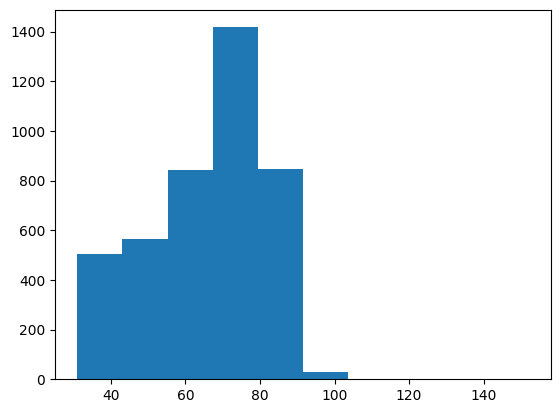

In [34]:
words_count = []

for p in all_paragraphs:
    words_count.append(len(p.split()))

plt.hist(words_count)

# Evaluation data of the retreiver 

In [35]:
if not (Path(OUTPUT_DIR/"retriev_eval_questions.json").exists()):
    api_key = os.getenv("OPENAI_API_KEY")
    client = OpenAI(api_key=api_key)

    retriev_eval_questions = []


    for i, text in enumerate(all_paragraphs):
        prompt = f"""
        Generate between 1 and 5 factual questions from the paragraph.

        Determine the number of questions based on the amount of DISTINCT,
        MEANINGFUL information in the paragraph:

        - 1 question: very little meaningful information
        - 2 questions: a small amount of meaningful information
        - 3 questions: a moderate amount of meaningful information
        - 4 questions: a substantial amount of meaningful information
        - 5 questions: a very information-dense paragraph

        Each question must:
        - Be answerable using ONLY the paragraph.
        - Target a different meaningful piece of information.
        - Be something a realistic user might ask.
        - Not require outside knowledge.
        - Not be redundant with another question.

        Do not generate more questions simply because the paragraph is long.
        Base the number on how many distinct pieces of information would be useful
        to retrieve.

        Paragraph:
        {text}

        Return ONLY the questions, one per line.
        """

        response = client.responses.create(
            model="gpt-5.6-luna",
            input=prompt
        )

        retriev_eval_questions.append(
            {
                "paragraph_id": i,
                "question" : response.output_text.splitlines()
            }
        )
    with open(OUTPUT_DIR/"retriev_eval_questions.json", "w", encoding="utf-8") as f:
        json.dump(retriev_eval_questions, f, indent=2, ensure_ascii=False)

In [36]:
retriev_eval_questions = get_data("retriev_eval_questions.json")

retriev_eval_questions

[{'paragraph_id': 0,
  'question': ['Who were Tony Stark’s parents?  ',
   'What roles did Tony Stark hold in relation to Stark Industries and the Avengers?  ',
   'How did Tony Stark describe himself?']},
 {'paragraph_id': 1,
  'question': ['How did Stark’s wealth and technical knowledge affect his status after his parents’ deaths?',
   '',
   'What was Stark doing when he was kidnapped by the Ten Rings in Afghanistan?',
   '',
   'How did Stark escape from his captors?']},
 {'paragraph_id': 2,
  'question': ['Who did Obadiah Stane turn against?  ',
   'Who did Stark use several more armors against after returning home?  ',
   'What did Stark publicly reveal after his fight against Obadiah Stane?']},
 {'paragraph_id': 3,
  'question': ['What was causing Stark’s body to be poisoned?',
   '',
   'Who challenged Stark by attempting to destroy his legacy?',
   '',
   'What did Stark do after agreeing to serve as a consultant for S.H.I.E.L.D.?']},
 {'paragraph_id': 4,
  'question': ['Who d

# Building Retreiver

### Pre Process teh paragraphs so that they can fit within 512 token limit

In [15]:
context_tokenizer = DPRContextEncoderTokenizer.from_pretrained("facebook/dpr-ctx_encoder-single-nq-base")
context_encoder = DPRContextEncoder.from_pretrained("facebook/dpr-ctx_encoder-single-nq-base").to(cuda)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] DPRContextEncoder LOAD REPORT from: facebook/dpr-ctx_encoder-single-nq-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
ctx_encoder.bert_model.pooler.dense.bias   | UNEXPECTED |  | 
ctx_encoder.bert_model.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [16]:
batche_size = 64
all_embeddings = []

context_encoder.eval()
with torch.no_grad():
    for i in range(0, len(all_paragraphs), batche_size):
        batch = all_paragraphs[i: i + batche_size]
        batch_tokens = context_tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors='pt'
        ).to(cuda)
        batch_outputs = context_encoder(**batch_tokens)
        all_embeddings.append(batch_outputs.pooler_output)

all_embeddings = torch.cat(all_embeddings, dim=0).cpu()

In [17]:
n_clusters = 20
n_samples = len(all_embeddings)
n_components = 3

sub_embeddings = all_embeddings[:n_samples]
sub_paragraphs = all_paragraphs[:n_samples]

tsne = TSNE(n_components, perplexity=sub_embeddings.shape[0]-1)
data_3d = tsne.fit_transform(sub_embeddings)
kmean = KMeans(n_clusters, random_state=42, n_init=10)
cluster_labels = kmean.fit_predict(sub_embeddings)

df = pd.DataFrame({
    'idx': range(n_samples),
    'x': data_3d[:, 0],
    'y': data_3d[:, 1],
    'z' : data_3d[:, 2],
    'cluster': cluster_labels.astype(str),
    'label': pages[:n_samples],  # <- replace with your list of page titles/character names, same order as all_paragraphs
    'text_preview': [p[:50] + '...' for p in sub_paragraphs]  # short preview for hover
})

# Step 4: Interactive scatter plot
fig = px.scatter_3d(
    df, x='x', y='y', z='z',
    color='cluster',
    hover_data=['idx','label', 'text_preview'],
    title='t-SNE of Marvel Wiki Paragraph Embeddings',
    width=1000, height=800
)
fig.update_traces(marker=dict(size=10, opacity=0.7))
fig.show()

# Faiss 

In [18]:
embedding_dim = all_embeddings.shape[1]

context_embeddings_np = all_embeddings.numpy().astype('float32')

index = faiss.IndexFlatIP(embedding_dim)
index.add(context_embeddings_np)

# Question Encoder and Tokenizer

In [19]:
question_encoder = DPRQuestionEncoder.from_pretrained('facebook/dpr-question_encoder-single-nq-base')
question_tokenizer = DPRQuestionEncoderTokenizer.from_pretrained('facebook/dpr-question_encoder-single-nq-base')

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] DPRQuestionEncoder LOAD REPORT from: facebook/dpr-question_encoder-single-nq-base
Key                                             | Status     |  | 
------------------------------------------------+------------+--+-
question_encoder.bert_model.pooler.dense.weight | UNEXPECTED |  | 
question_encoder.bert_model.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# Query and Context Retreival

In [20]:
question = "Who is steve rogers?"
question_tokens = question_tokenizer(question, return_tensors='pt')
question_embedding = question_encoder(**question_tokens).pooler_output.detach().numpy()

D, I = index.search(question_embedding, k=3)
print("D:", D)
print("I:", I)

print("Top 5 relevant contexts:")
for i, idx in enumerate(I[0]):
    print(f"{i+1}: {all_paragraphs[idx]}")
    print(f"distance {D[0][i]}\n")

D: [[81.21253  78.25496  78.229546]]
I: [[ 593 2353  599]]
Top 5 relevant contexts:
1: Captain Steven Grant "Steve" Rogers is a World War II veteran, a founding member of the Avengers, and Earth's first known superhero. Rogers grew up suffering from numerous health problems, and upon the United States' entry into World War II, he was rejected from serving in the United States Army despite several attempts to enlist.
distance 81.21253204345703

2: Rogers awakens in a 1940s-style hospital room. Deducing from an anachronistic radio broadcast that he was out of place, he flees outside into what is revealed to be present-day Times Square, where Nick Fury tells him he has been "asleep" for nearly 70 years. Stunned by this revelation, Rogers' only response is that he had a date.
distance 78.25495910644531

3: Rogers then joined S.H.I.E.L.D. as a counter-terrorist operative. While uncovering a conspiracy inside the organization, he encountered the Winter Soldier, and discovered that Hydra had 

In [21]:
def search_relevant_contexts(question, question_tokenizer, question_encoder, index, k=5):
    """
    Searches for the most relevant contexts to a given question.

    Returns:
    tuple: Distances and indices of the top k relevant contexts.
    """
    # Tokenize the question
    question_inputs = question_tokenizer(question, return_tensors='pt')

    # Encode the question to get the embedding
    question_embedding = question_encoder(**question_inputs).pooler_output.detach().numpy()

    # Search the index to retrieve top k relevant contexts
    D, I = index.search(question_embedding, k)

    return D, I

# LLM

In [22]:
llm_tokenizer = AutoTokenizer.from_pretrained("openai-community/gpt2")
model = AutoModelForCausalLM.from_pretrained("openai-community/gpt2")
model.generation_config.pad_token_id = llm_tokenizer.pad_token_id

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [23]:
contexts = "what is a LLM?"

inputs_tokenizer = llm_tokenizer(contexts, return_tensors='pt', max_length=1024, truncation=True)
summary_ids = model.generate(inputs_tokenizer['input_ids'], max_length=50, num_beams=4, early_stopping=True, pad_token_id=llm_tokenizer.eos_token_id)
summary_ids

summary = llm_tokenizer.decode(summary_ids[0], skip_special_tokens=True)
print(summary)

what is a LLM?

A LLM is a set of instructions that can be used to execute a program. A LLM is a set of instructions that can be used to execute a program. A LLM is a set of instructions


In [28]:
def generate_answer(question, contexts, tokenizer=llm_tokenizer, model=model):
    input_text =  question + " " + "".join(contexts)
    tokenized = tokenizer(input_text, return_tensors='pt', max_length=1024, truncation=True)
    answer_tokens = model.generate(tokenized['input_ids'], max_new_tokens=50, num_beams=4, early_stopping=True, pad_token_id=tokenizer.eos_token_id)

    return tokenizer.decode(answer_tokens[0], skip_special_tokens=True)

In [29]:
question = "Who is Thor?"
_ , I = search_relevant_contexts(question, question_tokenizer, question_encoder, index, 3)
contexts = [d for i, d in enumerate(all_paragraphs) if i in I]

generate_answer(question, contexts)

"Who is Thor? Thor Odinson is the Asgardian God of Thunder, the former king of both Asgard and New Asgard, a founding member of the Avengers, and a former member of the Guardians of the Galaxy. When his irresponsible and impetuous behavior reignited an ancient war between Asgard and Jotunheim, Thor was denied the right to become king, stripped of his power and hammer Mjølnir and he was banished to Earth by Odin.He is therefore extremely masterful in many areas of combat and with more than a millennium of training and combat experience, including hand-to-hand combat and various forms of weaponry available in Asgard, primarily swords and spears, though he usually prefers to wield his hammer Mjølnir. Thor is known to be very cunning and intuitive in battles and in warfare, having fought and defeated many enemies throughout his life.The film finds Thor on a journey unlike anything he's ever faced — a quest for inner peace. But his retirement is interrupted by a galactic killer known as Gor

In [31]:
question = "how did thor start a war"
_ , I = search_relevant_contexts(question, question_tokenizer, question_encoder, index, 3)
contexts = [d for i, d in enumerate(all_paragraphs) if i in I]

generate_answer(question, contexts)

"how did thor start a war Born during the 960s A.D., Thor had an idyllic childhood, brought up in Asgard as the most treasured son of Odin and his wife Frigga, but he was falsely led to believe that he was the firstborn child of the Allfather. When Thor was still a baby, he was carried by Frigga into battle alongside the Einherjar.Thor then trained in the Asgard Royal Training Hall, knocking down Magic targets with Mjølnir, but not long after, the Nine Realms were endangered by Marauders, which had put Vanaheim, the home of Hogun, in danger of invasion.Thor ran to the aid of his people and arrived just in time to witness his own mother, Frigga, fall down bleeding on the ground from being stabbed in the heart by Kurse. In great anger, Thor burned half of Malekith's face off with a lightning bolt and then threw his hammer, Mjølnir, into Kurse and Malekith, sending them back to their Ark ship and repelling the invasion, although Thor was unable to kill either of them or destroy their ship

In [ ]:
contexts

['Born during the 960s A.D., Thor had an idyllic childhood, brought up in Asgard as the most treasured son of Odin and his wife Frigga, but he was falsely led to believe that he was the firstborn child of the Allfather. When Thor was still a baby, he was carried by Frigga into battle alongside the Einherjar.',
 'Thor then trained in the Asgard Royal Training Hall, knocking down Magic targets with Mjølnir, but not long after, the Nine Realms were endangered by Marauders, which had put Vanaheim, the home of Hogun, in danger of invasion.',
 "Thor ran to the aid of his people and arrived just in time to witness his own mother, Frigga, fall down bleeding on the ground from being stabbed in the heart by Kurse. In great anger, Thor burned half of Malekith's face off with a lightning bolt and then threw his hammer, Mjølnir, into Kurse and Malekith, sending them back to their Ark ship and repelling the invasion, although Thor was unable to kill either of them or destroy their ship before it van

: 